# 14. Bundled Worlds

TidalPy ships worlds that can be built by name: rocky and icy moons, Mercury and Earth, Jupiter and Neptune (Jupiter also as the simplified `jupiter_simple`), the Sun, and the TRAPPIST-1 system. Each world's TOML file gives a published mass and radius and an interior whose equation of state reproduces that mass. Comments in the file give each number's source and what the interior was, and was not, fitted to. Some worlds also come in variants: `earth_prem_q` takes PREM's seismic quality factors (notebook 20), and `europa_dynamic`, `luna_dynamic`, `mercury_dynamic`, and `pluto_dynamic` solve their liquid layers as dynamic, compressible liquids (notebook 18).

This notebook compares the solved masses and moments of inertia with the values quoted in the files, solves Love numbers, and applies the worlds to Jupiter's interior, Pluto's ocean, Io's heat budget, and the TRAPPIST-1 planets.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import au
from TidalPy.Structures import System, available_worlds, build_world

SECONDS_PER_DAY = 86400.0
EARTH_MASS = 5.9721986e24  # [kg]

# Names accepted by build_world
bundled_names = available_worlds()
print(f"{len(bundled_names)} bundled worlds:")
print(", ".join(bundled_names))

26 bundled worlds:
charon, earth_prem, earth_prem_q, earth_simple, europa, europa_dynamic, io, jupiter, jupiter_simple, luna, luna_dynamic, mercury, mercury_dynamic, neptune, pluto, pluto_dynamic, sol, trappist1, trappist1b, trappist1c, trappist1d, trappist1e, trappist1f, trappist1g, trappist1h, triton


## Building a World by Name

`build_world` takes a bundled name, a path to a TOML file, or a dictionary. On first use the bundled files are copied to `Worlds/` in the user data directory. Later builds read that copy, so a world can be changed by editing its file there. The returned class depends on the world's `type`: `TerrestrialWorld`, `GasGiantWorld`, or `StarWorld`.

A built world has layers but no interior profile. `solve_eos` integrates the equation of state from the center to the surface and sets the solved mass, moment of inertia, and surface gravity. `summary()` lists a world's layers with their materials, solved densities, temperatures, and rheologies.

Each layer carries its material and its physics switches. Io's warm silicate layers melt (`use_melting` and `use_pressure_melting` on, with peridotite melting curves and Henning weakening), and its layers with radiogenic heating have `use_heating` on. Io's file pins the solve to its prescribed layer temperatures (`solve_temperature = false` in its `[eos_solver]` table), which sit below the solidus, so its fitted results hold. A thermal solve (`solve_eos(solve_temperature=True, ...)`, notebook 15) lets the temperature, and so the melt, follow the interior.

In [2]:
# Build Io from its bundled file and solve its interior structure
io = build_world("io")
io.solve_eos(raise_on_fail=True)
print(io.summary())
for layer in io:
    print(f"    {layer.name:14} tidal: {layer.use_tides}, melting: {layer.use_melting}, "
          f"pressure melting: {layer.use_pressure_melting}, heating: {layer.use_heating}")
print(f"solved mass {io.planet_mass_eos:.4e} kg, surface gravity {io.surface_gravity_eos:.4f} m/s^2")

# The other world families
for name in ("jupiter", "sol", "trappist1"):
    print(repr(build_world(name)))

TerrestrialWorld 'Io': radius 1821.49 km, mass 8.9298e+22 kg, 3 layers, EOS solved
  layer          radii [km]          state  material      density [kg m-3]  temperature [K]  rheology
  core           0 to 810            auto   solid         5150 to 5150      1900             maxwell
  mantle         810 to 1721.49      auto   solid+liquid  3360 to 3466      1600             andrade
  asthenosphere  1721.49 to 1821.49  auto   solid+liquid  3200 to 3214      1600             andrade
    core           tidal: True, melting: False, pressure melting: False, heating: True
    mantle         tidal: True, melting: True, pressure melting: True, heating: True
    asthenosphere  tidal: True, melting: True, pressure melting: True, heating: True
solved mass 8.9298e+22 kg, surface gravity 1.7964 m/s^2
GasGiantWorld('Jupiter', radius_km=69911, mass_kg=1.8981e+27, num_layers=3)
StarWorld('Sol', radius_km=695700, mass_kg=1.9884e+30, num_layers=0)
StarWorld('TRAPPIST-1', radius_km=82927.4, mass_kg=1.7

## Mass and Moment of Inertia

For each rocky and icy world, the table compares the solved mass with the stated mass, and the solved moment-of-inertia factor $C/(M R^2)$ with the measured value quoted in its file. Here $C$ \[kg m$^2$\] is the polar moment of inertia, and the solved factor is the world's `moment_of_inertia_factor`. The last column gives the difference in units of the measurement's 1-sigma uncertainty.

Each interior has one density fitted to the stated mass, so the mass column checks the fit. The moment-of-inertia factor measures how centrally concentrated the mass is. Only Luna's crust thickness and Earth-Simple's densities are fitted to it, so for Io, Europa, and Mercury it is an independent check of the interior. Earth-PREM takes its densities from PREM, with nothing fitted. Pluto, Charon, Triton, and the TRAPPIST-1 planets have no measured moment of inertia, so their factor is a model result.

In [3]:
# Measured C/(M R^2) and its 1-sigma uncertainty (None where it is far below the digits shown)
measured_moi_factor = {
    "io": (0.37685, 0.00035),  # Anderson et al. (2001)
    "europa": (0.346, 0.005),  # Anderson et al. (1998)
    "luna": (0.3931, 0.0002),  # Williams et al. (2014)
    "mercury": (0.346, 0.014),  # Margot et al. (2012)
    "earth_simple": (0.3307, None),  # Williams (1994)
    "earth_prem": (0.3307, None),  # Williams (1994), the same Earth
}
rocky_names = ["io", "europa", "luna", "mercury", "earth_simple", "earth_prem", "pluto", "charon", "triton",
               "trappist1b", "trappist1c", "trappist1d", "trappist1e", "trappist1f", "trappist1g", "trappist1h"]

solved_worlds = {}
print(f"{'world':13} {'stated mass [kg]':>17} {'solved/stated - 1':>18} {'C/MR^2':>8} {'measured':>17} "
      f"{'difference':>11} {'sigma':>6}")
for name in rocky_names:
    world = build_world(name)
    world.solve_eos(raise_on_fail=True)
    solved_worlds[name] = world
    mass_error = world.planet_mass_eos / world.mass - 1.0
    moi_factor = world.moment_of_inertia_factor
    if name in measured_moi_factor:
        measured, uncertainty = measured_moi_factor[name]
        if uncertainty is None:
            measured_label, sigma_label = f"{measured:.5f}", "-"
        else:
            measured_label = f"{measured:.5f} +/- {uncertainty:.5f}"
            sigma_label = f"{(moi_factor - measured) / uncertainty:+.1f}"
        comparison = f"{measured_label:>17} {100.0 * (moi_factor / measured - 1.0):+10.2f}% {sigma_label:>6}"
    else:
        comparison = f"{'-':>17} {'-':>11} {'-':>6}"
    print(f"{name:13} {world.mass:17.5e} {mass_error:18.1e} {moi_factor:8.5f} {comparison}")

world          stated mass [kg]  solved/stated - 1   C/MR^2          measured  difference  sigma
io                  8.92980e+22            5.1e-09  0.38319 0.37685 +/- 0.00035      +1.68%  +18.1
europa              4.79980e+22            3.6e-09  0.34374 0.34600 +/- 0.00500      -0.65%   -0.5
luna                7.34579e+22           -6.1e-09  0.39312 0.39310 +/- 0.00020      +0.00%   +0.1
mercury             3.30103e+23           -1.8e-10  0.34646 0.34600 +/- 0.01400      +0.13%   +0.0
earth_simple        5.97200e+24            2.1e-07  0.33070           0.33070      -0.00%      -
earth_prem          5.97200e+24            5.9e-04  0.33094           0.33070      +0.07%      -
pluto               1.30246e+22           -9.5e-09  0.31855                 -           -      -
charon              1.58968e+21            2.1e-08  0.31156                 -           -      -
triton              2.14029e+22           -2.9e-08  0.31554                 -           -      -
trappist1b          8.

Every fitted interior reproduces its stated mass to better than one part in a million. Earth-PREM, whose densities are not fitted, is off by 0.06 percent. Where a factor is measured, the solved values for Luna, Europa, and Mercury fall within their 1-sigma uncertainties, and both Earths are within 0.1 percent of Earth's value. Io's is 1.7 percent high, 18 times the formal uncertainty of its measurement (a value derived from Io's gravity field assuming hydrostatic equilibrium). The Io file notes that its core radius is the parameter to adjust if that difference matters.

## Love Numbers

`solve_love_numbers(frequency, degree_l=2, ...)` solves the radial problem on the solved interior at a tidal forcing frequency \[rad s$^{-1}$\], with each layer's rheology evaluated at that frequency. The complex results are stored as `love_number_k`, `love_number_h`, and `love_number_l`, and `love_q_k` gives the tidal quality factor $Q = |k_2| / (-\mathrm{Im}\,k_2)$ (for a positive Re $k_2$).

The table compares the degree-2 Love number $k_2$ with the published values quoted in the files. Luna, Mercury, and Earth-Simple each have their mantle shear modulus fitted to that value. Jupiter and Neptune are fitted only to their mass and moment-of-inertia factor, so their $k_2$ is an independent result. Their layers are all static fluids, so their Love number does not depend on frequency and they do not dissipate (an infinite $Q$).

In [4]:
# (world, forcing period [days] or None for the fluid planets, published k2, source)
published_love = [
    ("luna", 27.3217, 0.02422, "Williams et al. (2014)"),
    ("mercury", 87.9691, 0.569, "Genova et al. (2019)"),
    ("earth_simple", 12.4206 / 24.0, 0.30, "Wahr (1981), M2 period"),
    ("jupiter", None, 0.565, "Durante et al. (2020), Juno"),
    ("neptune", None, 0.41, "Durda (1992)"),
]

print(f"{'world':13} {'period [d]':>10} {'Re(k2)':>8} {'Q':>7} {'published':>10} {'difference':>11}  source")
for name, period_days, published_k2, source in published_love:
    if name in solved_worlds:
        world = solved_worlds[name]
    else:
        world = build_world(name)
        world.solve_eos(raise_on_fail=True)
    if period_days is None:
        world.solve_love_numbers()  # Default frequency. A static fluid's response does not depend on it
        period_label = "-"
    else:
        world.solve_love_numbers(2.0 * np.pi / (period_days * SECONDS_PER_DAY))  # Forcing frequency [rad/s]
        period_label = f"{period_days:.4f}"
    k2 = world.love_number_k
    print(f"{name:13} {period_label:>10} {k2.real:8.5f} {world.love_q_k:7.1f} {published_k2:10.5f} "
          f"{100.0 * (k2.real / published_k2 - 1.0):+10.1f}%  {source}")

# Luna's tidal quality factor at the month and the year
luna = solved_worlds["luna"]
for period_days, published_q in ((27.3217, "38 +/- 4"), (365.25, "41 +/- 9")):
    luna.solve_love_numbers(2.0 * np.pi / (period_days * SECONDS_PER_DAY))
    print(f"Luna Q at {period_days:8.4f} days: {luna.love_q_k:5.1f}  (Williams and Boggs 2015: {published_q})")

world         period [d]   Re(k2)       Q  published  difference  source
luna             27.3217  0.02422    37.9    0.02422       +0.0%  Williams et al. (2014)
mercury          87.9691  0.56897   120.2    0.56900       -0.0%  Genova et al. (2019)
earth_simple      0.5175  0.29996   246.3    0.30000       -0.0%  Wahr (1981), M2 period
jupiter                -  0.53438     inf    0.56500       -5.4%  Durante et al. (2020), Juno
neptune                -  0.42667     inf    0.41000       +4.1%  Durda (1992)
Luna Q at  27.3217 days:  37.9  (Williams and Boggs 2015: 38 +/- 4)
Luna Q at 365.2500 days:  40.9  (Williams and Boggs 2015: 41 +/- 9)


The three fitted bodies reproduce their $k_2$ to within 0.1 percent. With nothing tuned to $k_2$, Jupiter's solved value is 5 percent below the $0.565 \pm 0.006$ that Juno measured (Durante et al. 2020) and 9 percent below the hydrostatic 0.590 its file's tide model uses. This spherical solve leaves out Jupiter's rotation, which raises $k_2$. Neptune's is 4 percent above its published value. Luna's low-viscosity zone at the base of its mantle is fitted to the two lunar $Q$ values, and both fall within the published uncertainty.

Jupiter and Neptune use a fixed-$Q$ tide model, which reads $k_2$ and $Q$ from the `[tides]` table in their files. Their solved Love number checks the interior but is not used in their tidal heating.

## Jupiter and Jupiter-Simple

`jupiter_simple` is one uniform layer at Jupiter's mean density. It reproduces the mass but gives the uniform-sphere $C/(M R^2) = 0.4$ and the fluid-sphere $k_2 = 1.5$. `jupiter` has a dense core, a metallic hydrogen mantle, and a molecular hydrogen envelope, with the two outer densities fitted to the mass and to $C/(M R^2) = 0.264$. Concentrating mass toward the center lowers both numbers. `get_density` returns the density at a float or an array of radii \[m\].

Jupiter         mass 1.8981e+27 kg, C/MR^2 = 0.2640, k2 = 0.5344
Jupiter-Simple  mass 1.8980e+27 kg, C/MR^2 = 0.4000, k2 = 1.5000
Jupiter layer masses:
    core         16.2 Earth masses
    mantle      268.4 Earth masses
    envelope     33.2 Earth masses


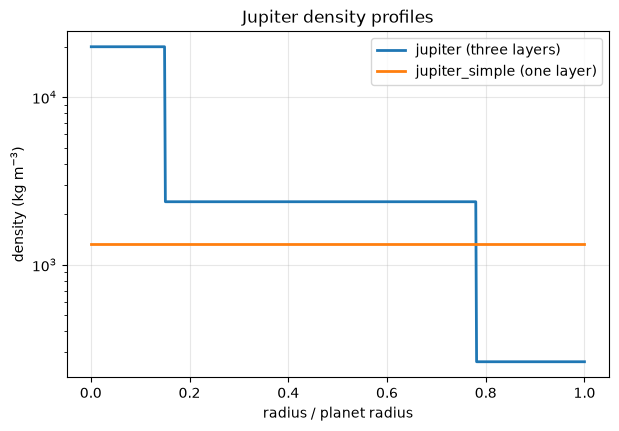

In [5]:
jupiter = build_world("jupiter")
jupiter_simple = build_world("jupiter_simple")

fig, ax = plt.subplots(figsize=(7, 4.5))
for world, label in ((jupiter, "jupiter (three layers)"), (jupiter_simple, "jupiter_simple (one layer)")):
    world.solve_eos(raise_on_fail=True)
    world.solve_love_numbers()  # Frequency-independent for these static fluid layers
    print(f"{world.name:15} mass {world.planet_mass_eos:.4e} kg, C/MR^2 = {world.moment_of_inertia_factor:.4f}, "
          f"k2 = {world.love_number_k.real:.4f}")

    radii = np.linspace(1.0e-3, 1.0, 600) * world.radius  # [m]
    ax.plot(radii / world.radius, world.get_density(radii), lw=2, label=label)

print("Jupiter layer masses:")
for layer in jupiter:
    print(f"    {layer.name:9} {layer.mass / EARTH_MASS:7.1f} Earth masses")

ax.set_yscale("log")
ax.set_xlabel("radius / planet radius")
ax.set_ylabel("density (kg m$^{-3}$)")
ax.set_title("Jupiter density profiles")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

The layered interior puts 16 Earth masses in a 20000 kg m$^{-3}$ core within 0.15 of the radius. Its file lists the limits of a model with one density per layer. For example, the solved central pressure is more than twice the value from published interior models. A calculation that needs a resolved pressure or density profile needs a finer interior.

## Pluto's Ocean

Pluto's file places a 165 km ice shell over a 112 km liquid water ocean on a rock core. The ocean's material is liquid-only water, so the radial solver treats it as a static liquid, which decouples the shell from the core. Giving the ocean of a second copy of Pluto the ice shell's material, rheology, and temperature freezes the ocean into the shell. The ocean's file also sets `use_tides = false`, since a liquid layer has no shear dissipation, and a layer with `use_tides` off deforms with its static moduli and no rheology. The frozen ocean therefore turns `use_tides` on, so its ice responds with the shell's rheology like the rest of the shell. Re-solving that copy's equation of state and Love number shows what the ocean contributes. Both solves use the 6.387 day mutual period of Pluto and Charon, which is also Pluto's spin period.

In [6]:
pluto = solved_worlds["pluto"]
frozen_pluto = build_world("pluto")
# Layers are accessed by name. The ocean takes the shell's ice, rheology, and temperature
frozen_pluto.ocean.material = frozen_pluto.ice_shell.material
frozen_pluto.ocean.shear_rheology = frozen_pluto.ice_shell.shear_rheology
frozen_pluto.ocean.temperature = frozen_pluto.ice_shell.temperature
frozen_pluto.ocean.use_tides = True  # Viscoelastic like the shell's ice, not held at its static moduli
frozen_pluto.solve_eos(raise_on_fail=True)
print(f"ocean is liquid: {pluto.ocean.is_liquid}, frozen ocean is liquid: {frozen_pluto.ocean.is_liquid}")

tidal_frequency = pluto.spin_frequency  # Synchronous, so this is the mutual orbital frequency [rad/s]
love_k2 = {}
for label, world in (("with ocean", pluto), ("ocean frozen", frozen_pluto)):
    world.solve_love_numbers(tidal_frequency)
    love_k2[label] = world.love_number_k
    print(f"{label:13} k2 = {world.love_number_k.real:.6f}   h2 = {world.love_number_h.real:.4f}   "
          f"-Im(k2) = {-world.love_number_k.imag:.3e}")
print(f"The ocean raises k2 by a factor of {love_k2['with ocean'].real / love_k2['ocean frozen'].real:.1f}")

ocean is liquid: True, frozen ocean is liquid: False
with ocean    k2 = 0.145781   h2 = 0.4731   -Im(k2) = 2.634e-02
ocean frozen  k2 = 0.004574   h2 = 0.0107   -Im(k2) = 4.299e-04
The ocean raises k2 by a factor of 31.9


With the ocean, $k_2$ is 32 times larger than for the frozen body. Pluto has no measured $k_2$, so nothing in the file is fitted to it. The shell and ocean thicknesses are also estimates. Published values range from 65 to 260 km for the shell and 50 to 283 km for the ocean (sources are in the file's comments).

## Io's Heat Budget

Io's interior has a thin, melt-weakened asthenosphere under a solid mantle. The asthenosphere viscosity is fitted to one tidal observable: Io's total heat output of $(9.33 \pm 1.83) \times 10^{13}$ \[W\] from the astrometry of Lainey et al. (2009), with Jupiter's mass and Io's orbit ($a$ = 4.217e8 m, $e$ = 0.0041, synchronous rotation). Bundled worlds carry no orbital state, so Io and Jupiter are put in a `System` with Jupiter as Io's tidal host, and `synchronous=True` sets Io's spin to its mean motion. `calc_tides()` then takes the orbit from the system and returns the total heating and each layer's share. Io's file sets no tide model, so the builder attaches the rheology model, which solves the Love number from the interior at each tidal frequency.

The cell also computes the dissipation of Io's tide in Jupiter with `calc_pair_evolution`, which solves the tide each body raises in the other on their shared orbit. Jupiter uses the fixed-$Q$ model in its file ($k_2/Q$ from Lainey et al. 2009).

In [7]:
jupiter_io = System("Jupiter-Io")
jupiter_io.add_world(jupiter)
jupiter_io.add_world(
    io,
    tidal_host=jupiter,
    semi_major_axis=4.217e8,  # [m]
    eccentricity=0.0041,
    synchronous=True)  # Spin = mean motion

io_tides = io.calc_tides()  # Orbit, spin, and host mass from the system
io_heating = io_tides["tidal_heating"]  # [W]
io_flux = io.get_tidal_heat_flux()  # [W/m^2]
print(f"Io tidal heating      : {io_heating:.3e} W (Lainey et al. 2009: 9.33e13 +/- 1.83e13 W)")
print(f"Io surface heat flux  : {io_flux:.2f} W/m^2")
for layer_name, layer_heating in io_tides["layer_tidal_heating"].items():
    print(f"    {layer_name:14} {layer_heating:.3e} W ({100.0 * layer_heating / io_heating:.4f} percent)")

# Both bodies' tides on the shared orbit. "host" is the tide Io raises in Jupiter, with Jupiter's own spin
jupiter_part = jupiter_io.calc_pair_evolution(io)["host"]
print(f"Dissipation in Jupiter from Io's tide: {jupiter_part['tidal_heating']:.3e} W")
print(f"Jupiter's spin energy loss           : {-jupiter_part['dE_spin_dt']:.3e} W")
print(f"Gain of Io's orbital energy from it  : {jupiter_part['dE_orbit_dt']:.3e} W")

Io tidal heating      : 9.330e+13 W (Lainey et al. 2009: 9.33e13 +/- 1.83e13 W)
Io surface heat flux  : 2.24 W/m^2
    core           6.012e+08 W (0.0006 percent)
    mantle         3.814e+12 W (4.0875 percent)
    asthenosphere  8.948e+13 W (95.9119 percent)
Dissipation in Jupiter from Io's tide: 3.523e+14 W
Jupiter's spin energy loss           : 4.598e+14 W
Gain of Io's orbital energy from it  : 1.075e+14 W


Io's heating matches the astrometric value, about 2.2 W m$^{-2}$ at the surface (`get_tidal_heat_flux`), and 96 percent of it is in the asthenosphere. `calc_tides` finds each layer's share from the depth-resolved radial solution, so the layer values sum to the total. The dissipation in Jupiter is about four times Io's. Jupiter rotates faster than Io orbits, so all of that energy comes from Jupiter's spin: the spin loses $4.6 \times 10^{14}$ W, of which $3.5 \times 10^{14}$ W heats Jupiter and the rest, $1.1 \times 10^{14}$ W, goes into Io's orbit, which Jupiter's tide raises.

## TRAPPIST-1 Planets

The seven TRAPPIST-1 planets share one recipe: an incompressible iron core under a silicate mantle, with the core radius fitted to each planet's mass (Agol et al. 2021). Each planet is added to a `System` about the star `trappist1` at the semi-major axis quoted in its file (Agol et al. 2021), with `synchronous=True`. Each planet's $k_2$ is solved at its orbital period.

The eccentricities follow from the transit-timing fits of Agol et al. (2021), which give $e\cos\omega$ and $e\sin\omega$, as $e = \sqrt{(e\cos\omega)^2 + (e\sin\omega)^2}$. All are below 0.01. For planets b and c the uncertainty of each component exceeds the eccentricity itself, so their eccentricities are consistent with zero.

The mantle viscosities are unconstrained, nominal Earth-like values, so the heating shows the trend with orbit rather than a prediction. Spin and mean motion must agree closely. Each planet file's spin is the synchronous rate of its measured period, which differs from the mean motion of the quoted, rounded semi-major axis by up to 0.06 percent. A mismatch that small leaves a slow tidal mode that can multiply the heating, and TidalPy warns about a spin this close to, but not at, the mean motion. `synchronous=True` sets each spin to the mean motion the system computes, so the two agree exactly.

planet       a [au] period [d]        e  Re(k2)   -Im(k2)  heating [W]  flux [W/m^2]
TRAPPIST-1b 0.01154     1.5110  0.00305  0.4691  1.02e-03    7.004e+15     1.103e+01
TRAPPIST-1c 0.01580     2.4207  0.00055  0.4594  1.13e-03    2.200e+13     3.584e-02
TRAPPIST-1d 0.02227     4.0507  0.00563  0.2456  1.48e-03    4.386e+13     1.385e-01
TRAPPIST-1e 0.02925     6.0974  0.00632  0.3375  1.64e-03    1.719e+13     3.981e-02
TRAPPIST-1f 0.03849     9.2039  0.00842  0.4153  2.10e-03    9.432e+12     1.693e-02
TRAPPIST-1g 0.04683    12.3519  0.00401  0.4680  2.52e-03    8.696e+11     1.337e-03
TRAPPIST-1h 0.06189    18.7666  0.00365  0.2247  2.37e-03    1.120e+10     3.851e-05
planet b's heat flux is 4.9 times Io's


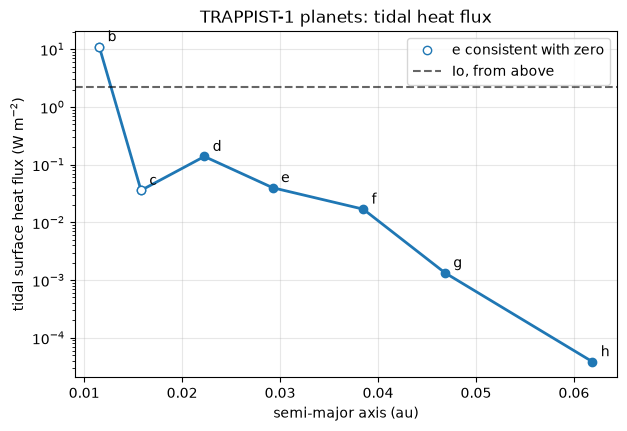

In [8]:
trappist1 = build_world("trappist1")
# Planet: (semi-major axis [au], e cos(w), e sin(w)), all from Agol et al. (2021), Table 2
trappist_orbits = {
    "trappist1b": (0.01154, -0.00215, 0.00217),
    "trappist1c": (0.01580, 0.00055, 0.00001),
    "trappist1d": (0.02227, -0.00496, 0.00267),
    "trappist1e": (0.02925, 0.00433, -0.00461),
    "trappist1f": (0.03849, -0.00840, -0.00051),
    "trappist1g": (0.04683, 0.00380, 0.00128),
    "trappist1h": (0.06189, -0.00365, -0.00002),
}

trappist_system = System("TRAPPIST-1")
trappist_system.add_world(trappist1, is_star=True)
semi_major_axes, heat_fluxes = [], []
print(f"{'planet':11} {'a [au]':>7} {'period [d]':>10} {'e':>8} {'Re(k2)':>7} {'-Im(k2)':>9} "
      f"{'heating [W]':>12} {'flux [W/m^2]':>13}")
for name, (semi_major_axis_au, e_cos_w, e_sin_w) in trappist_orbits.items():
    planet = solved_worlds[name]
    eccentricity = float(np.hypot(e_cos_w, e_sin_w))
    trappist_system.add_world(
        planet,
        tidal_host=trappist1,
        semi_major_axis=semi_major_axis_au * au,
        eccentricity=eccentricity,
        synchronous=True)  # Spin = mean motion
    mean_motion = trappist_system.calc_orbital_frequency(planet)  # [rad/s]
    planet.solve_love_numbers(mean_motion)
    k2 = planet.love_number_k
    heating = planet.calc_tides()["tidal_heating"]  # [W], orbit from the system
    flux = planet.get_tidal_heat_flux()  # [W/m^2]
    semi_major_axes.append(semi_major_axis_au)
    heat_fluxes.append(flux)
    period_days = 2.0 * np.pi / mean_motion / SECONDS_PER_DAY
    print(f"{planet.name:11} {semi_major_axis_au:7.5f} {period_days:10.4f} {eccentricity:8.5f} {k2.real:7.4f} "
          f"{-k2.imag:9.2e} {heating:12.3e} {flux:13.3e}")
print(f"planet b's heat flux is {heat_fluxes[0] / io_flux:.1f} times Io's")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogy(semi_major_axes, heat_fluxes, "o-", lw=2)
# Open markers for b and c, whose eccentricities are consistent with zero
ax.plot(semi_major_axes[:2], heat_fluxes[:2], "o", color="tab:blue", mfc="white", label="e consistent with zero")
for semi_major_axis_au, flux, name in zip(semi_major_axes, heat_fluxes, trappist_orbits):
    ax.annotate(name[-1], (semi_major_axis_au, flux), textcoords="offset points", xytext=(6, 4))
ax.axhline(io_flux, color="k", ls="--", alpha=0.6, label="Io, from above")
ax.set_xlabel("semi-major axis (au)")
ax.set_ylabel("tidal surface heat flux (W m$^{-2}$)")
ax.set_title("TRAPPIST-1 planets: tidal heat flux")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

The heat flux falls by more than five orders of magnitude from planet b to planet h. For a fixed interior and radius, the leading-order heating scales as $e^2 a^{-15/2}$. The eccentricities differ by more than a factor of ten between planets, so the curve is not smooth. Planet c has the smallest eccentricity and falls below both of its neighbors. Planet b, the innermost, has a tidal heat flux about 4.9 times Io's. The eccentricities of b and c are consistent with zero, so their heating, which scales as $e^2$, is the least certain: zero is within the uncertainties.